# Profiles & phase diagrams — a step-by-step guide

`profile`, `phase`, `profile3d`, `rotationcurve` and `profiletimeseries` are **general, weighted
reductions** over any Mera field — a *profile* bins by one quantity (often a **radius**) and reports
per-bin **statistics** of another; a *phase diagram* is a 2-D weighted histogram. They work on
**3-D data** (gas / gravity / particles) **and on projected 2-D maps**.

This guide builds the core features up one at a time, on **one galaxy**. Seven sections cover the
essentials with a plot each; the remaining features share the same API and are summarised at the end.

## Setup — load the galaxy once

Load hydro, gravity and clumps from one snapshot, plus a companion run that carries **particles**
(dark matter + stars). Define a reusable physical **center**; profiles take a `center` in any length unit.

In [1]:
using Mera, CairoMakie
CairoMakie.activate!()
BASE = "/Volumes/FASTStorage/Simulations/Mera-Tests"   # <-- change me
info  = getinfo(100, joinpath(BASE,"RAMSES/spiral_clumps"), verbose=false)
gas   = gethydro(info,  verbose=false, show_progress=false)
grav  = getgravity(info, lmax=gas.lmax, verbose=false, show_progress=false)
parts = getparticles(getinfo(1, joinpath(BASE,"RAMSES/spiral_ugrid"), verbose=false), verbose=false, show_progress=false)
ctr = [:bc]                         # box centre; e.g. [24.,24.,24.] with range_unit=:kpc also works
println("gas cells = ", length(gas.data), "   particles = ", length(parts.data))

gas cells = 590311   particles = 45470


## 1. The simplest profile — binning a quantity

With only a bin field, `profile` returns the **summed weight** per bin — e.g. the radial **mass
profile** M(R). The radius is measured about `center`; `nbins`, `xrange`, `scale` and units are
physical. `scale=:log` gives log-spaced bins (the low edge is clamped to the smallest positive
value; the top edge is inclusive). Set bins by **count** (`nbins`), by a **physical width**
(`binsize=0.5` in `xunit`, or `binsize=(500,:pc)` with its own unit; a dimensionless **dex** step
under `scale=:log`), or by fully custom `edges=` — `binsize`/`edges` override `nbins`. Returns `x`
(centres), `edges`, `count`, `sum` (Σweight), `sumw2`.

binsize=(500,:pc) → bin width [kpc] = 0.5

  (48 bins)


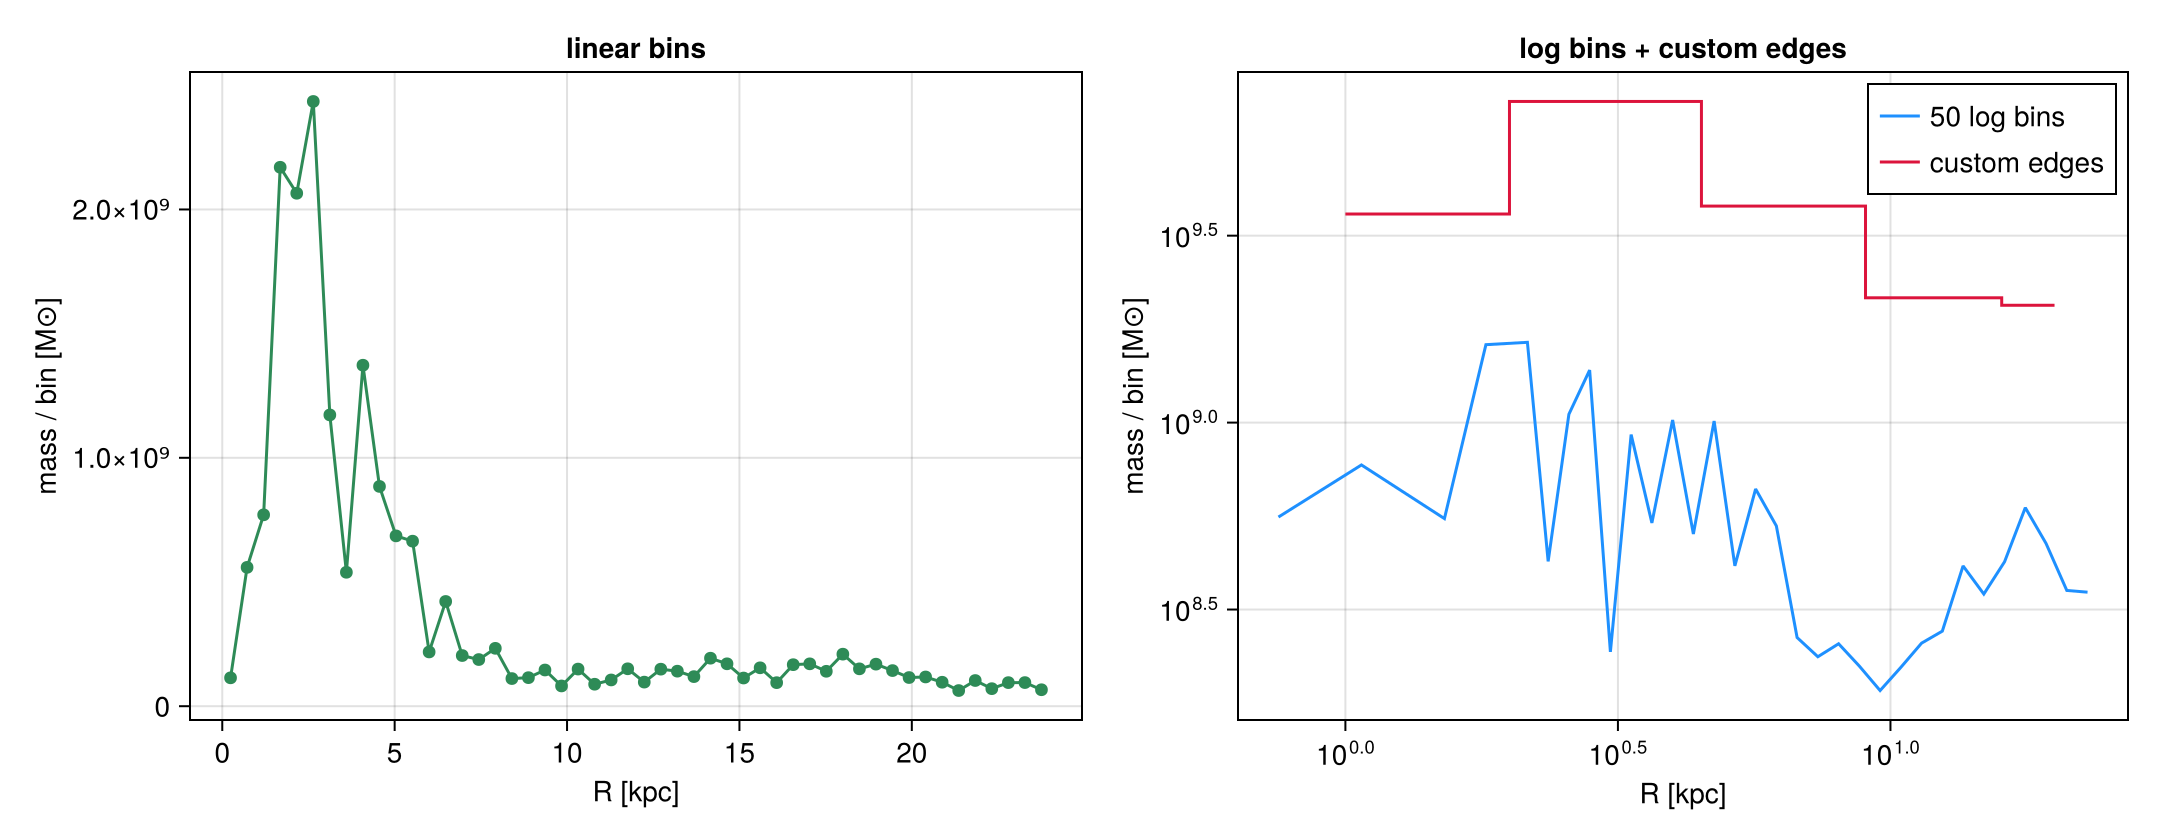

In [2]:
pl  = profile(gas, :r_cylinder; weight=:mass, nbins=50, xrange=(0,24), center=ctr, range_unit=:kpc, xunit=:kpc)
plg = profile(gas, :r_cylinder; weight=:mass, nbins=50, scale=:log, xrange=(0.3,24), center=ctr, range_unit=:kpc, xunit=:kpc)
pe  = profile(gas, :r_cylinder; weight=:mass, edges=[0.,2.,4.,8.,16.,24.], center=ctr, range_unit=:kpc, xunit=:kpc)
pbs = profile(gas, :r_cylinder; weight=:mass, binsize=(500,:pc), xrange=(0,24), center=ctr, range_unit=:kpc, xunit=:kpc)
println("binsize=(500,:pc) → bin width [kpc] = ", round(diff(pbs.edges)[1], digits=3), "  (", length(pbs.edges)-1, " bins)")
M(p) = p.sum .* gas.scale.Msol      # code mass -> Msol
fig = Figure(size=(1080,420))
ax1 = Axis(fig[1,1], xlabel="R [kpc]", ylabel="mass / bin [M⊙]", title="linear bins")
scatterlines!(ax1, pl.x, M(pl), color=:seagreen)
ax2 = Axis(fig[1,2], xscale=log10, yscale=log10, xlabel="R [kpc]", ylabel="mass / bin [M⊙]", title="log bins + custom edges")
o = M(plg) .> 0
lines!(ax2, plg.x[o], M(plg)[o], color=:dodgerblue, label="50 log bins")
stairs!(ax2, pe.x, max.(M(pe),1), color=:crimson, step=:center, label="custom edges")
axislegend(ax2, position=:rt); fig

## 2. Per-bin statistics — a binned statistic is not a histogram

Give a **second field** `yvar` and each bin carries the weight-weighted **`mean`**, **`std`**,
**`sem`** (standard error on the mean, `std/√neff` with the Kish effective sample size `neff`),
**`min`/`max`**, **`median`** and a **`quantiles`** matrix at the requested `qlevels`. A custom
`statistic=f` (called `f(yview, wview)` if it accepts weights, else `f(yview)`) adds a `custom`
column. One figure makes the whole spread visible.

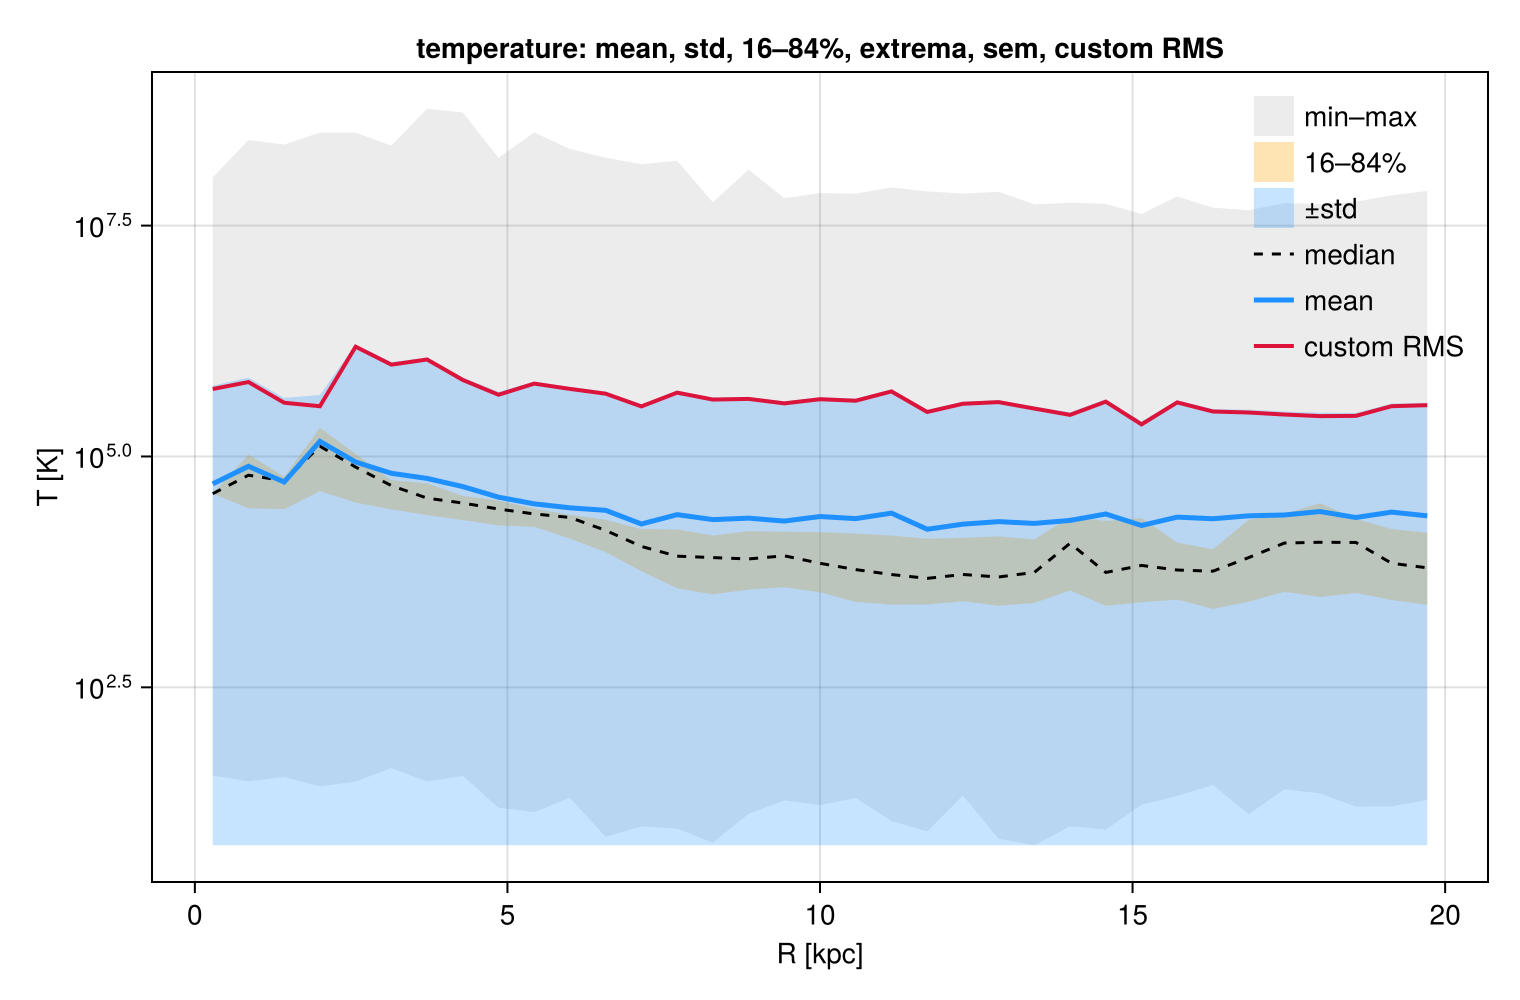

In [3]:
pT = profile(gas, :r_cylinder, :T; weight=:mass, unit=:K, nbins=35, xrange=(0,20), center=ctr, range_unit=:kpc, xunit=:kpc,
             quantiles=[0.16,0.5,0.84])
pC = profile(gas, :r_cylinder, :T; weight=:mass, unit=:K, nbins=35, xrange=(0,20), center=ctr, range_unit=:kpc, xunit=:kpc,
             statistic=(y,w)->sqrt(sum(w.*y.^2)/sum(w)))   # mass-weighted RMS -> pC.custom
ok = (pT.count .> 0) .& (pT.min .> 0) .& (pT.mean .> 0)
x=pT.x[ok]; mn=pT.min[ok]; mx=pT.max[ok]; q1=pT.quantiles[ok,1]; q3=pT.quantiles[ok,3]
mu=pT.mean[ok]; sd=pT.std[ok]; md_=pT.median[ok]; sem=pT.sem[ok]; rms=pC.custom[ok]; flo=minimum(mn)
fig = Figure(size=(760,500)); ax = Axis(fig[1,1], yscale=log10, xlabel="R [kpc]", ylabel="T [K]",
                                        title="temperature: mean, std, 16–84%, extrema, sem, custom RMS")
band!(ax, x, mn, mx, color=(:gray,0.15), label="min–max")
band!(ax, x, q1, q3, color=(:orange,0.30), label="16–84%")
band!(ax, x, max.(mu.-sd, flo), mu.+sd, color=(:dodgerblue,0.25), label="±std")
lines!(ax, x, md_, color=:black, linewidth=1.5, linestyle=:dash, label="median")
lines!(ax, x, mu, color=:dodgerblue, linewidth=2.5, label="mean")
lines!(ax, x, rms, color=:crimson, linewidth=2, label="custom RMS")
se = [i for i in 1:4:length(x) if mu[i]-sem[i] > 0]   # keep whiskers positive on the log axis
errorbars!(ax, x[se], mu[se], sem[se], color=:dodgerblue, whiskerwidth=6)
axislegend(ax, position=:rt, framevisible=false); fig

## 3. Density, enclosed mass & normalization (density PDF)

`geometry=:spherical` (shell `4/3·π·Δr³`) or `:cylindrical` (annulus `π·Δr²`) divides the binned
weight by the shell volume to give a physical **`density`** (`weight`-unit per `xunit`³, + `shell_volume`).
`cumulative=:forward` (or `:reverse`) adds `cumsum`/`cumcount` — the **enclosed mass** M(<r).
`normalize=:sum` gives per-bin `fraction` (Σ=1); `normalize=:pdf` gives a true probability density
`pdf` (∫=1). The canonical use is the **density PDF** — bin *by* density and normalize; the `weight`
then picks the **mass-weighted** vs **volume-weighted** ρ-PDF (they differ — the near-log-normal ISM
density distribution).

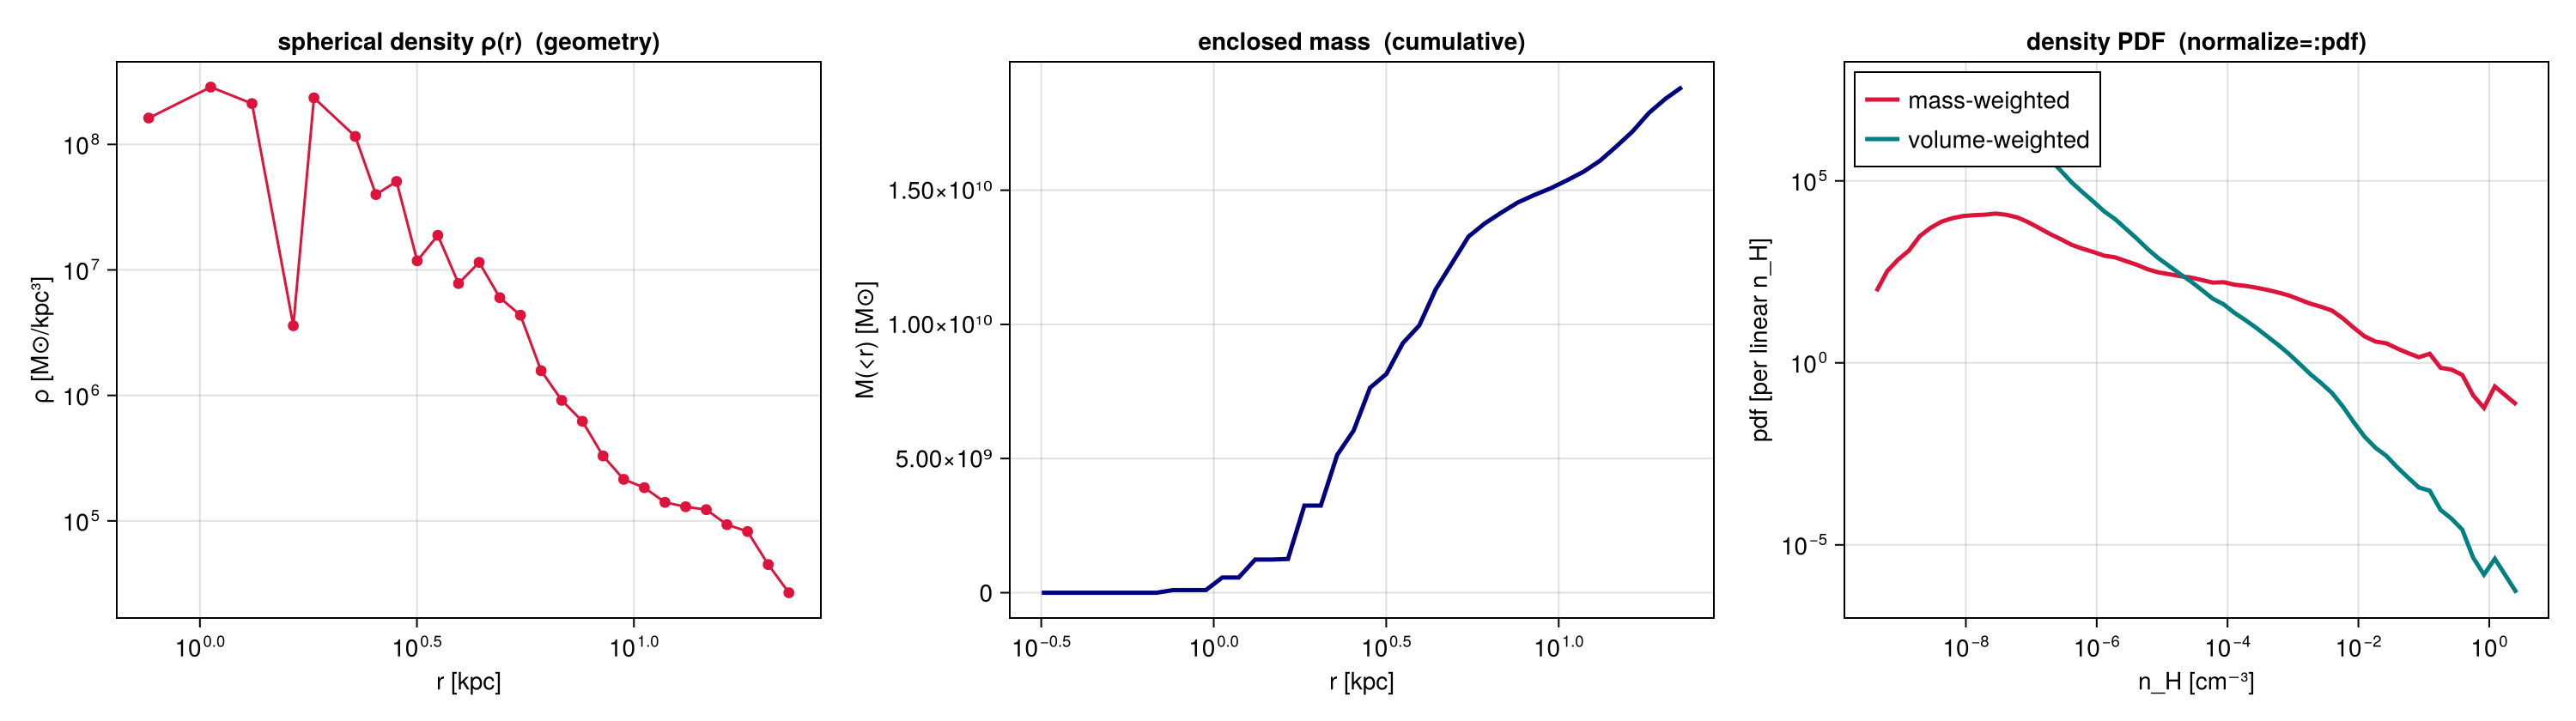

In [4]:
pr = profile(gas, :r_sphere; weight=:mass, geometry=:spherical, cumulative=:forward, scale=:log,
             xrange=(0.3,24), nbins=40, center=ctr, range_unit=:kpc, xunit=:kpc)
ρ = pr.density .* gas.scale.Msol; Menc = pr.cumsum .* gas.scale.Msol
dm = profile(gas, :rho; weight=:mass,   normalize=:pdf, scale=:log, unit=:nH, nbins=60)   # mass-weighted ρ-PDF
dv = profile(gas, :rho; weight=:volume, normalize=:pdf, scale=:log, unit=:nH, nbins=60)   # volume-weighted ρ-PDF
fig = Figure(size=(1500,420))
ax1 = Axis(fig[1,1], xscale=log10, yscale=log10, xlabel="r [kpc]", ylabel="ρ [M⊙/kpc³]", title="spherical density ρ(r)  (geometry)")
od = ρ .> 0; scatterlines!(ax1, pr.x[od], ρ[od], color=:crimson)
ax2 = Axis(fig[1,2], xscale=log10, xlabel="r [kpc]", ylabel="M(<r) [M⊙]", title="enclosed mass  (cumulative)")
lines!(ax2, pr.x, Menc, color=:navy, linewidth=2.5)
ax3 = Axis(fig[1,3], xscale=log10, yscale=log10, xlabel="n_H [cm⁻³]", ylabel="pdf [per linear n_H]", title="density PDF  (normalize=:pdf)")
om = dm.pdf .> 0; ov = dv.pdf .> 0
lines!(ax3, dm.x[om], dm.pdf[om], color=:crimson, linewidth=2.5, label="mass-weighted")
lines!(ax3, dv.x[ov], dv.pdf[ov], color=:teal,    linewidth=2.5, label="volume-weighted")
axislegend(ax3, position=:lt); fig

## 4. Weighting & components — mass vs volume vs none

`weight` is `:mass`, `:volume` (grid-only), `:none` (equal cells) or **any field**. Mass- and
volume-weighted means differ wherever density varies within a bin; `:none` is the unweighted mean.
Profiles work for every data type — but **gravity/RT carry no `:mass`** (use `:volume`/`:none`).
To combine components, profile each on **shared `edges`** (here gas vs DM vs stars enclosed mass).

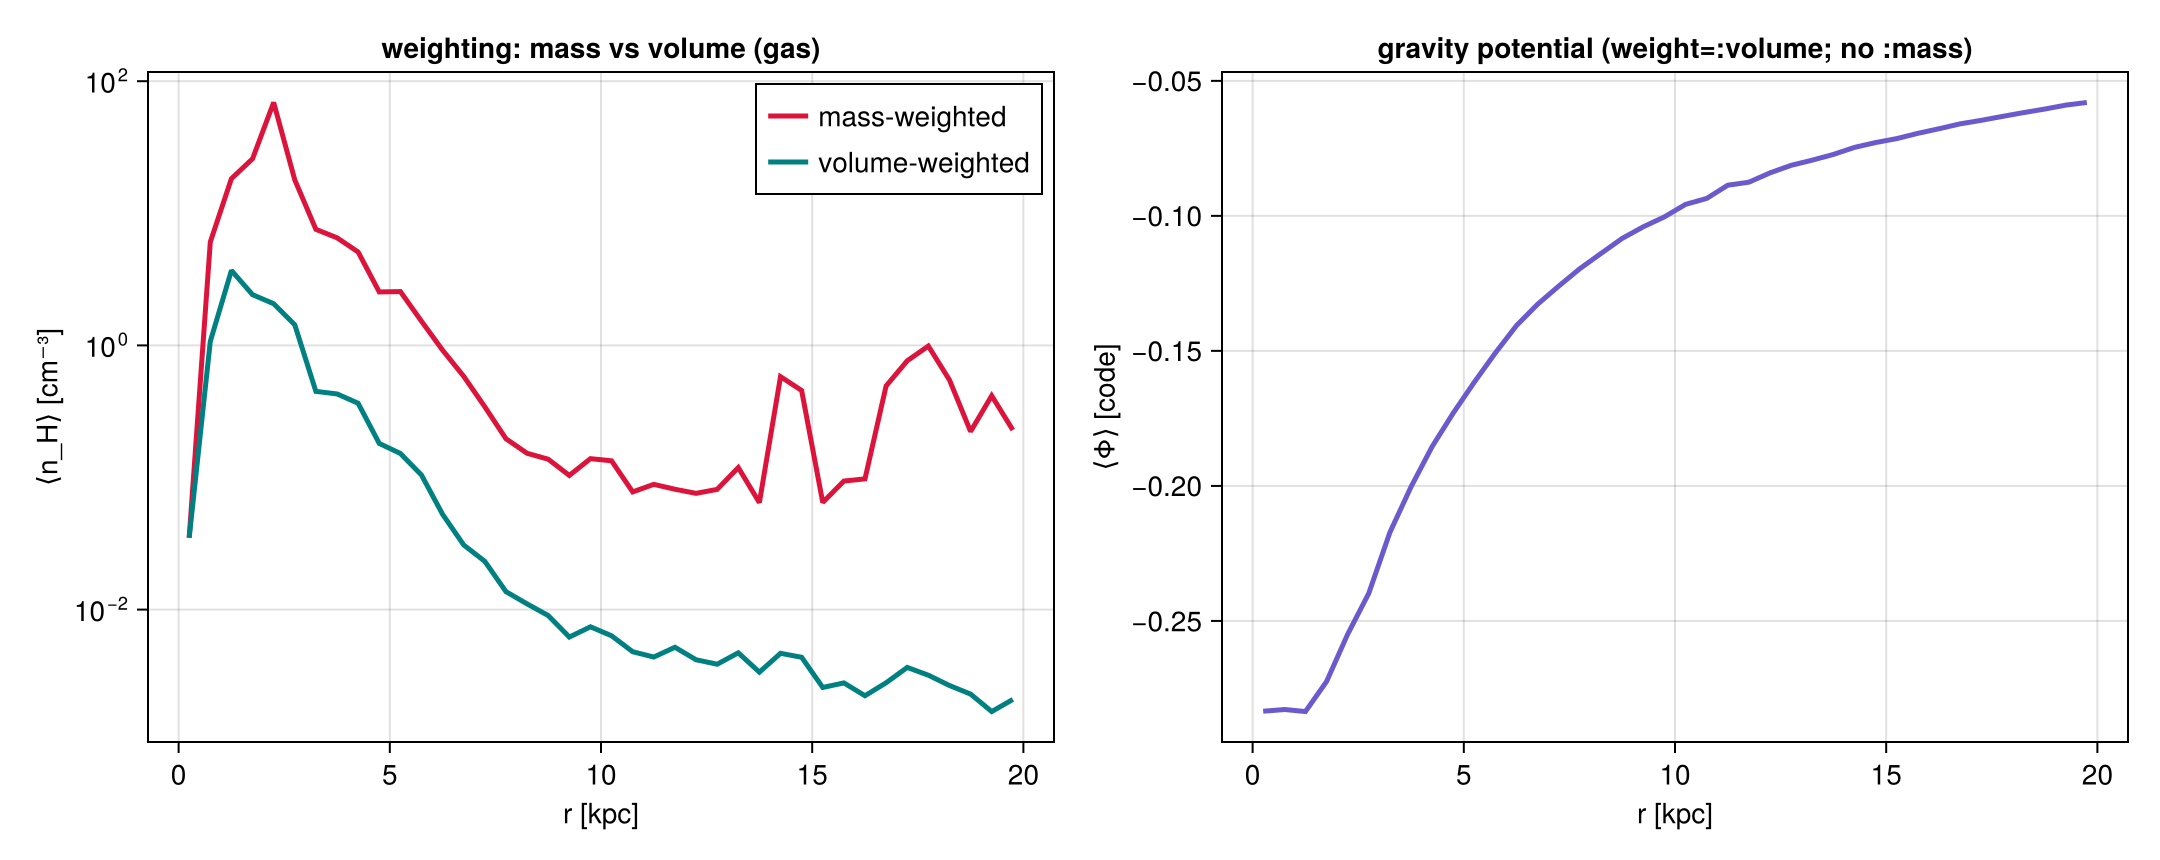

In [6]:
ed = collect(range(0,20,length=41))
pmw = profile(gas, :r_sphere, :rho; weight=:mass,   unit=:nH, edges=ed, center=ctr, range_unit=:kpc, xunit=:kpc)
pvw = profile(gas, :r_sphere, :rho; weight=:volume, unit=:nH, edges=ed, center=ctr, range_unit=:kpc, xunit=:kpc)
pep = profile(grav, :r_sphere, :epot; weight=:volume, edges=ed, center=ctr, range_unit=:kpc, xunit=:kpc)  # gravity: no :mass
fig = Figure(size=(1080,430))
ax1 = Axis(fig[1,1], yscale=log10, xlabel="r [kpc]", ylabel="⟨n_H⟩ [cm⁻³]", title="weighting: mass vs volume (gas)")
o1=(pmw.mean.>0); o2=(pvw.mean.>0)
lines!(ax1, pmw.x[o1], pmw.mean[o1], color=:crimson, linewidth=2.5, label="mass-weighted")
lines!(ax1, pvw.x[o2], pvw.mean[o2], color=:teal,    linewidth=2.5, label="volume-weighted")
axislegend(ax1, position=:rt)
ax2 = Axis(fig[1,2], xlabel="r [kpc]", ylabel="⟨Φ⟩ [code]", title="gravity potential (weight=:volume; no :mass)")
og=isfinite.(pep.mean); lines!(ax2, pep.x[og], pep.mean[og], color=:slateblue, linewidth=2.5); fig

## 5. Rotation curve — who contributes how much

`rotationcurve` forms the enclosed mass M(<r) and returns the **dynamical** circular velocity
`v_circ = √(G·M(<r)/r)`. Run it per **component** — gas (optionally **masked**, e.g. cold gas only),
stars, dark matter — and they add **in quadrature**, `v_tot² = Σ v_i²`. The squared ratio
`(v_i/v_tot)²` is exactly each component's **fractional contribution** to the rotational support. This
is the dynamical mass decomposition (≠ the *kinematic* ⟨v_ϕ⟩ of §7).

**How `v_circ` is estimated:** the enclosed mass `M(<r)` is an *exact* direct sum of the binned masses;
`v_circ = √(G·M(<r)/r)` is then the **spherical** (shell-theorem) idealization — it assumes spherical
symmetry, so for a flattened disk it under-shoots at large R. The third panel overplots it against the
**exact** curve from the solved gravity field, `v = √(R·|a_R|)` with `a_R = getvar(grav, :ar_cylinder)`
(the true radial acceleration of all matter) — the dynamically rigorous rotation curve.

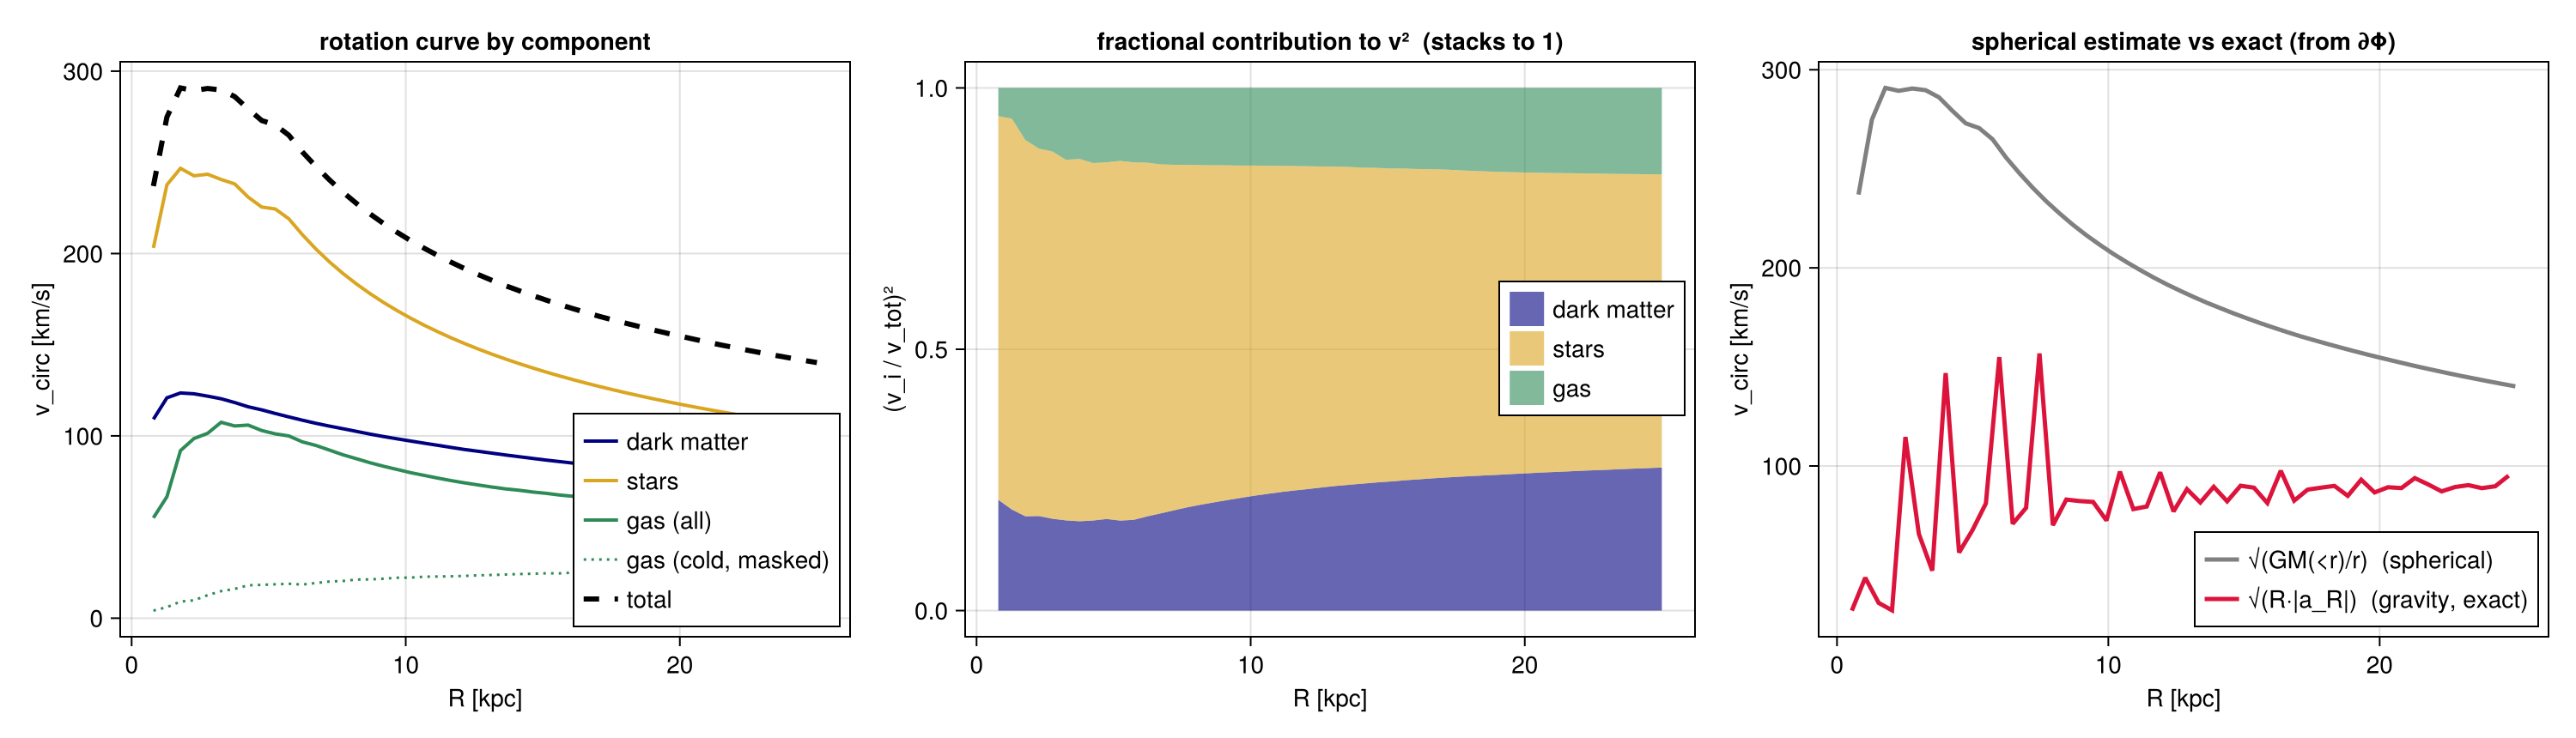

In [7]:
opts = (rvar=:r_cylinder, xunit=:kpc, center=ctr, range_unit=:kpc, nbins=50, xrange=(0.3,25))
rcg = rotationcurve(gas; opts...)                                  # all gas
cold = getvar(gas, :T, :K) .< 1e4                                  # a gas mask: cold gas (< 10⁴ K)
rcc = rotationcurve(gas; mask=cold, opts...)                       # cold-gas contribution
rcs = rotationcurve(parts; mask=getparticlemask(parts,:stars; verbose=false), opts...)
rcd = rotationcurve(parts; mask=getparticlemask(parts,:dm;    verbose=false), opts...)
vtot = sqrt.(rcg.v_circ.^2 .+ rcs.v_circ.^2 .+ rcd.v_circ.^2)       # spherical-estimate total
# EXACT curve from the solved gravity field: v = √(R·|a_R|), a_R = radial acceleration (all matter)
pa  = profile(grav, :r_cylinder, :ar_cylinder; weight=:volume, unit=:cm_s2, nbins=50, xrange=(0.3,25), center=ctr, range_unit=:kpc, xunit=:kpc)
Rcm = pa.x .* (Mera.getunit(info,:cm)/Mera.getunit(info,:kpc))
vexact = sqrt.(Rcm .* abs.(pa.mean)) ./ 1e5                        # km/s
fig = Figure(size=(1500,430))
ax1 = Axis(fig[1,1], xlabel="R [kpc]", ylabel="v_circ [km/s]", title="rotation curve by component")
lines!(ax1, rcd.x, rcd.v_circ, color=:navy,      linewidth=2, label="dark matter")
lines!(ax1, rcs.x, rcs.v_circ, color=:goldenrod, linewidth=2, label="stars")
lines!(ax1, rcg.x, rcg.v_circ, color=:seagreen,  linewidth=2, label="gas (all)")
lines!(ax1, rcc.x, rcc.v_circ, color=:seagreen,  linewidth=1.5, linestyle=:dot, label="gas (cold, masked)")
lines!(ax1, rcg.x, vtot, color=:black, linewidth=3, linestyle=:dash, label="total")
axislegend(ax1, position=:rb)
fd=(rcd.v_circ./vtot).^2; fs=(rcs.v_circ./vtot).^2; fg=(rcg.v_circ./vtot).^2
ax2 = Axis(fig[1,2], xlabel="R [kpc]", ylabel="(v_i / v_tot)²", title="fractional contribution to v²  (stacks to 1)")
band!(ax2, rcg.x, fill(0.0,length(rcg.x)), fd, color=(:navy,0.6), label="dark matter")
band!(ax2, rcg.x, fd, fd.+fs, color=(:goldenrod,0.6), label="stars")
band!(ax2, rcg.x, fd.+fs, fd.+fs.+fg, color=(:seagreen,0.6), label="gas")
axislegend(ax2, position=:rc)
ax3 = Axis(fig[1,3], xlabel="R [kpc]", ylabel="v_circ [km/s]", title="spherical estimate vs exact (from ∂Φ)")
lines!(ax3, rcg.x, vtot, color=:gray, linewidth=2.5, label="√(GM(<r)/r)  (spherical)")
lines!(ax3, pa.x, vexact, color=:crimson, linewidth=2.5, label="√(R·|a_R|)  (gravity, exact)")
axislegend(ax3, position=:rb); fig

## 6. Phase diagrams — colour is a knob

`phase` is a 2-D weighted histogram of two fields — the classic mass-weighted **ρ–T** diagram. With
a third field `cvar` each cell is coloured by the per-cell weighted **mean**; `cstat` swaps that for
`:std`/`:median`/`:min`/`:max`/`:full` or a function. `normalize=:pdf` makes a 2-D PDF, and
`xedges`/`yedges` accept custom edges. Same ρ–T plane, four different colourings:

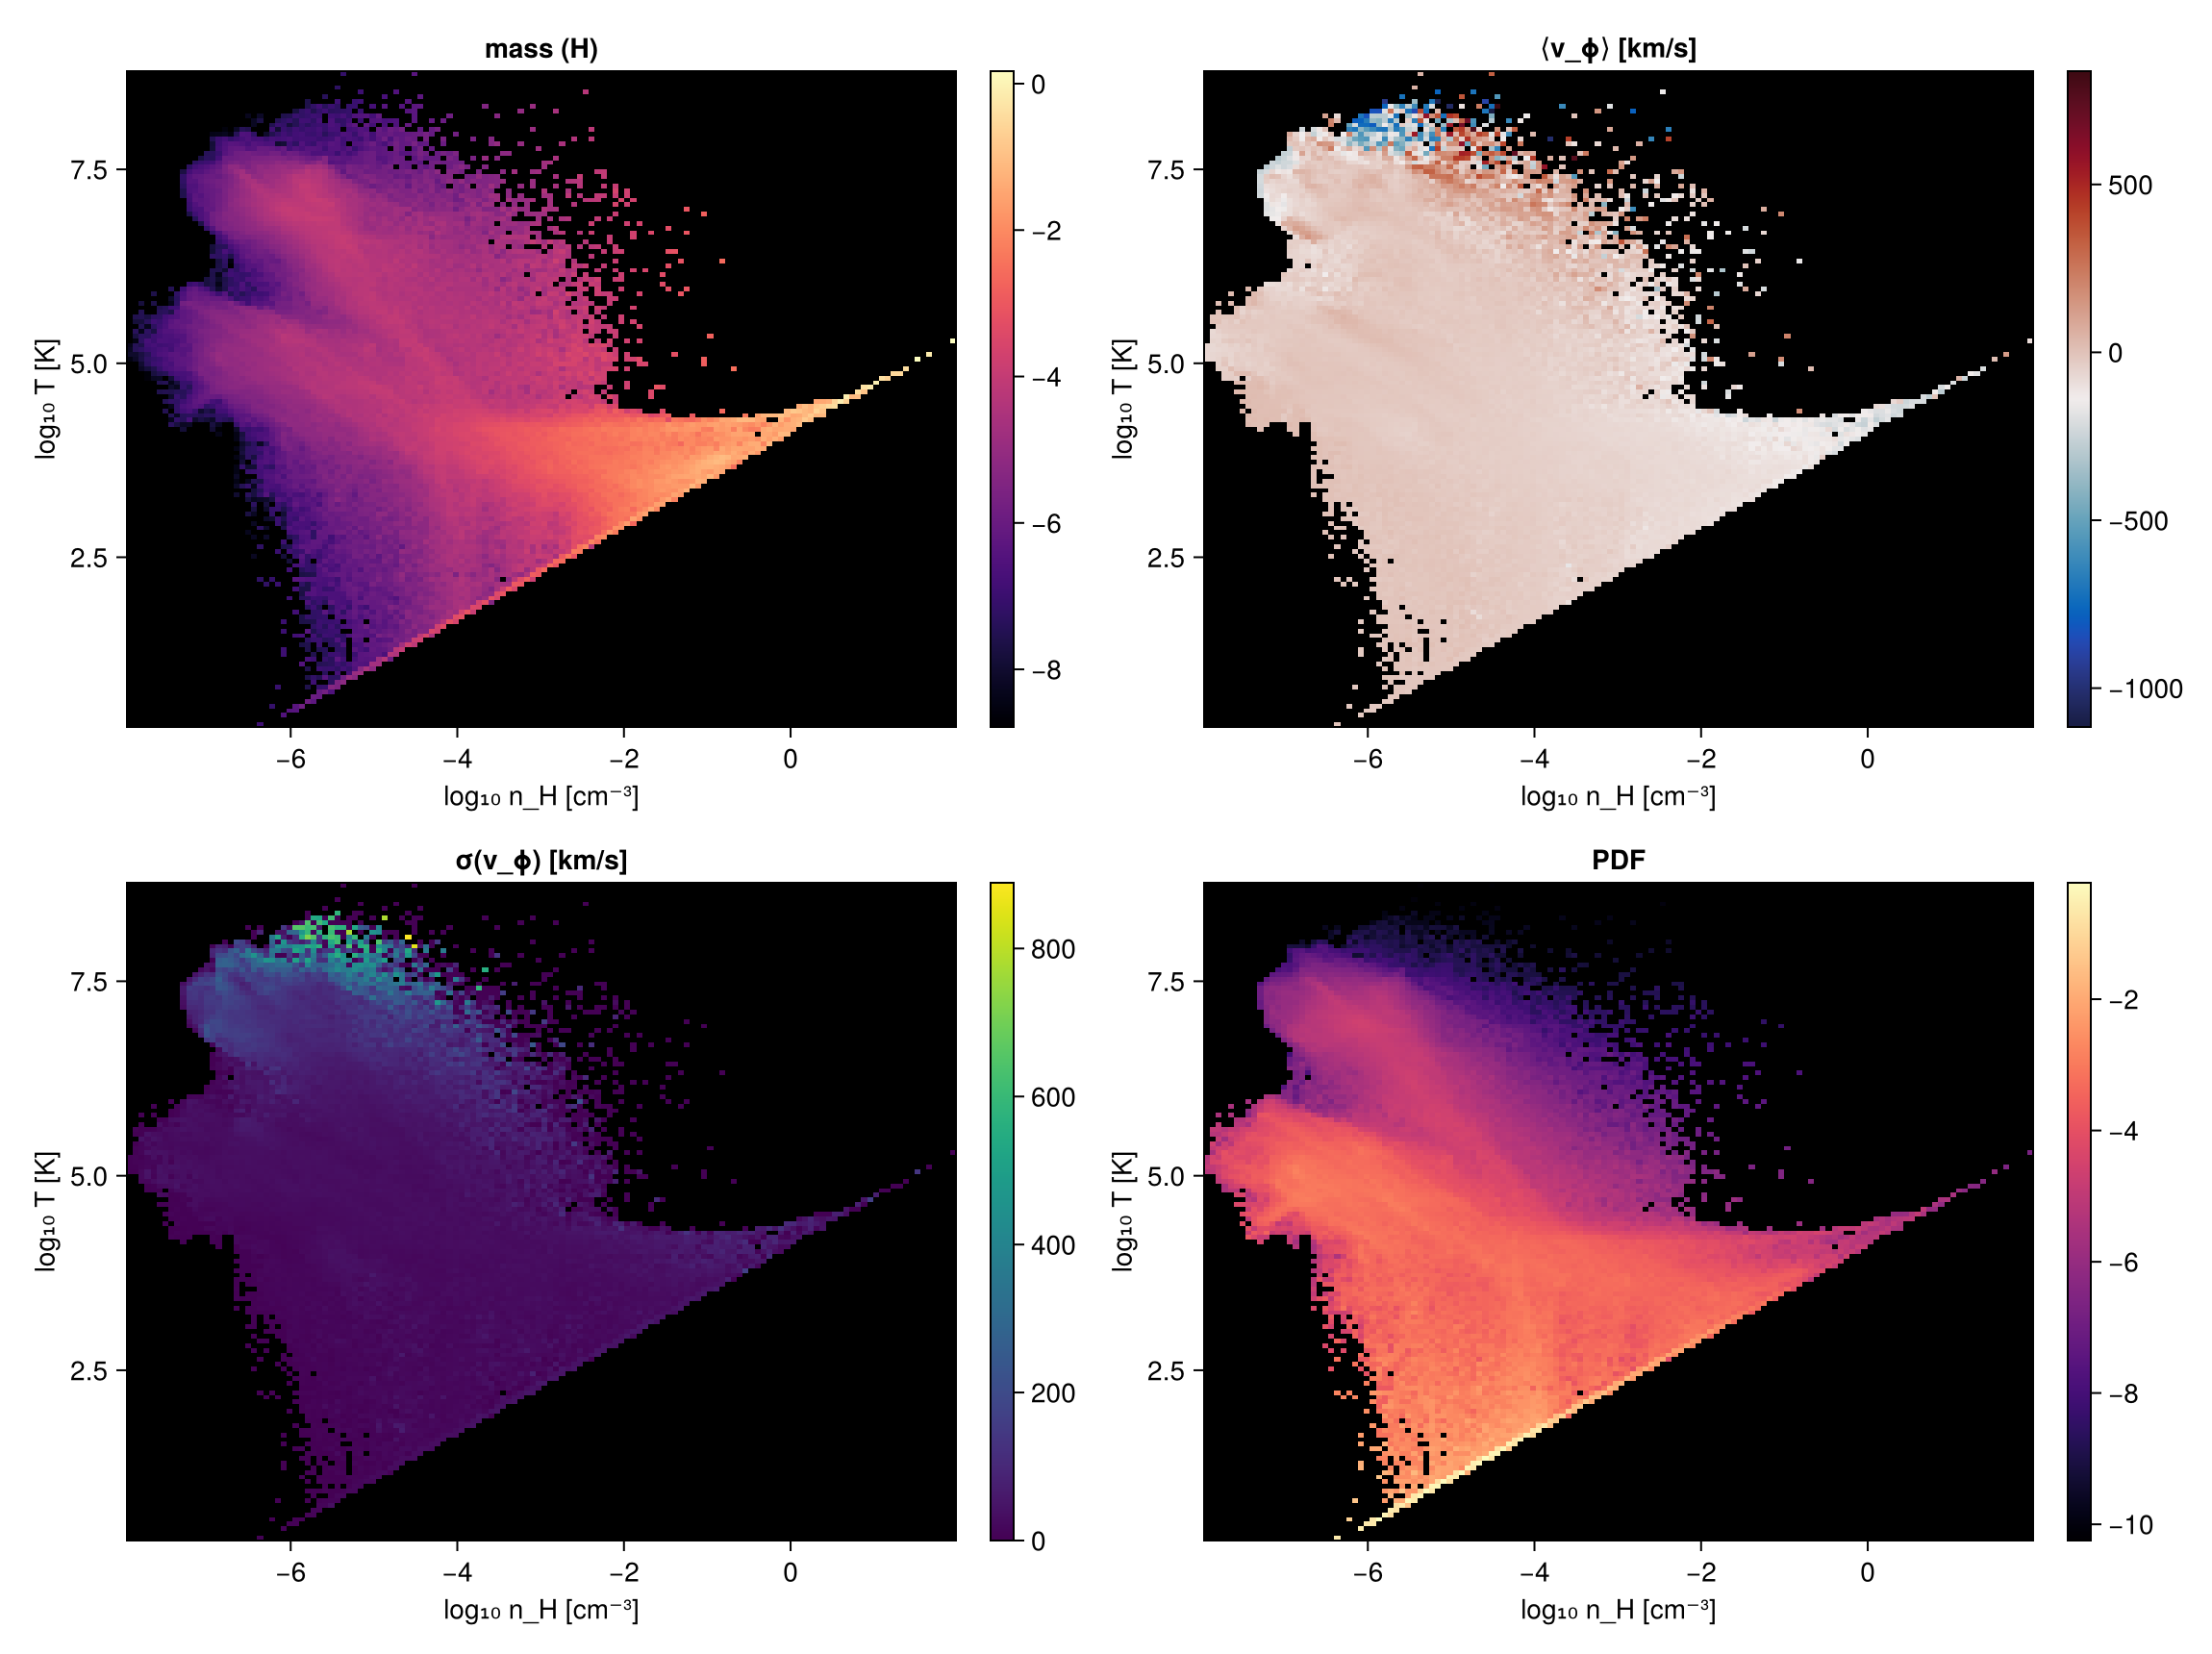

In [12]:
kw = (weight=:mass, nbins=(140,140), xscale=:log, yscale=:log, xunit=:nH, yunit=:K, center=ctr, range_unit=:kpc)
ph  = phase(gas, :rho, :T; kw...)
pcv = phase(gas, :rho, :T, :vϕ_cylinder; cstat=:mean, cunit=:km_s, kw...)
psd = phase(gas, :rho, :T, :vϕ_cylinder; cstat=:std,  cunit=:km_s, kw...)   # also :median/:min/:max/:full/callable
ppdf= phase(gas, :rho, :T; normalize=:pdf, kw...)
xc = log10.((ph.xedges[1:end-1].+ph.xedges[2:end])./2)
yc = log10.((ph.yedges[1:end-1].+ph.yedges[2:end])./2)
lg(M)=log10.(replace(M,0.0=>NaN)); fig=Figure(size=(1150,860))
for (k,(lab,M,cm,fn)) in enumerate((("mass (H)",ph.H,:magma,lg),("⟨v_ϕ⟩ [km/s]",pcv.mean,:balance,identity),
                                    ("σ(v_ϕ) [km/s]",psd.std,:viridis,identity),("PDF",ppdf.pdf,:magma,lg)))
    r=(k-1)÷2+1; c=2*((k-1)%2)+1
    ax=Axis(fig[r,c], xlabel="log₁₀ n_H [cm⁻³]", ylabel="log₁₀ T [K]", title=lab)
    A=fn(M); hm=heatmap!(ax, xc, yc, A, colormap=cm, nan_color=:black); Colorbar(fig[r,c+1], hm)
end
fig

## 7. Distribution shape & uncertainties — moments, equal-count bins, bootstrap CIs

Three statistics upgrades, all opt-in and composable:

* **`skewness`** and (excess) **`kurtosis`** are always returned with a `yvar` — the asymmetry and
  tail-weight of each bin's distribution (a Gaussian gives both ≈ 0).
* **`scale=:equal`** places *quantile-spaced* edges so every bin holds about the same number of
  points — far steadier statistics where the disk thins out (vs fixed-width bins that empty out).
* **`bootstrap=N`** resamples each bin to add confidence intervals for the per-bin mean and median
  (`mean_ci`/`median_ci`, `nbins×2`) plus `median_se`; `ci=:percentile` (default), `:basic` or
  `:bca` (bias-corrected & accelerated). It is deterministic (seeded), so reruns match.

equal-count points/bin (min..max): (

32300, 33260)  → nearly equal


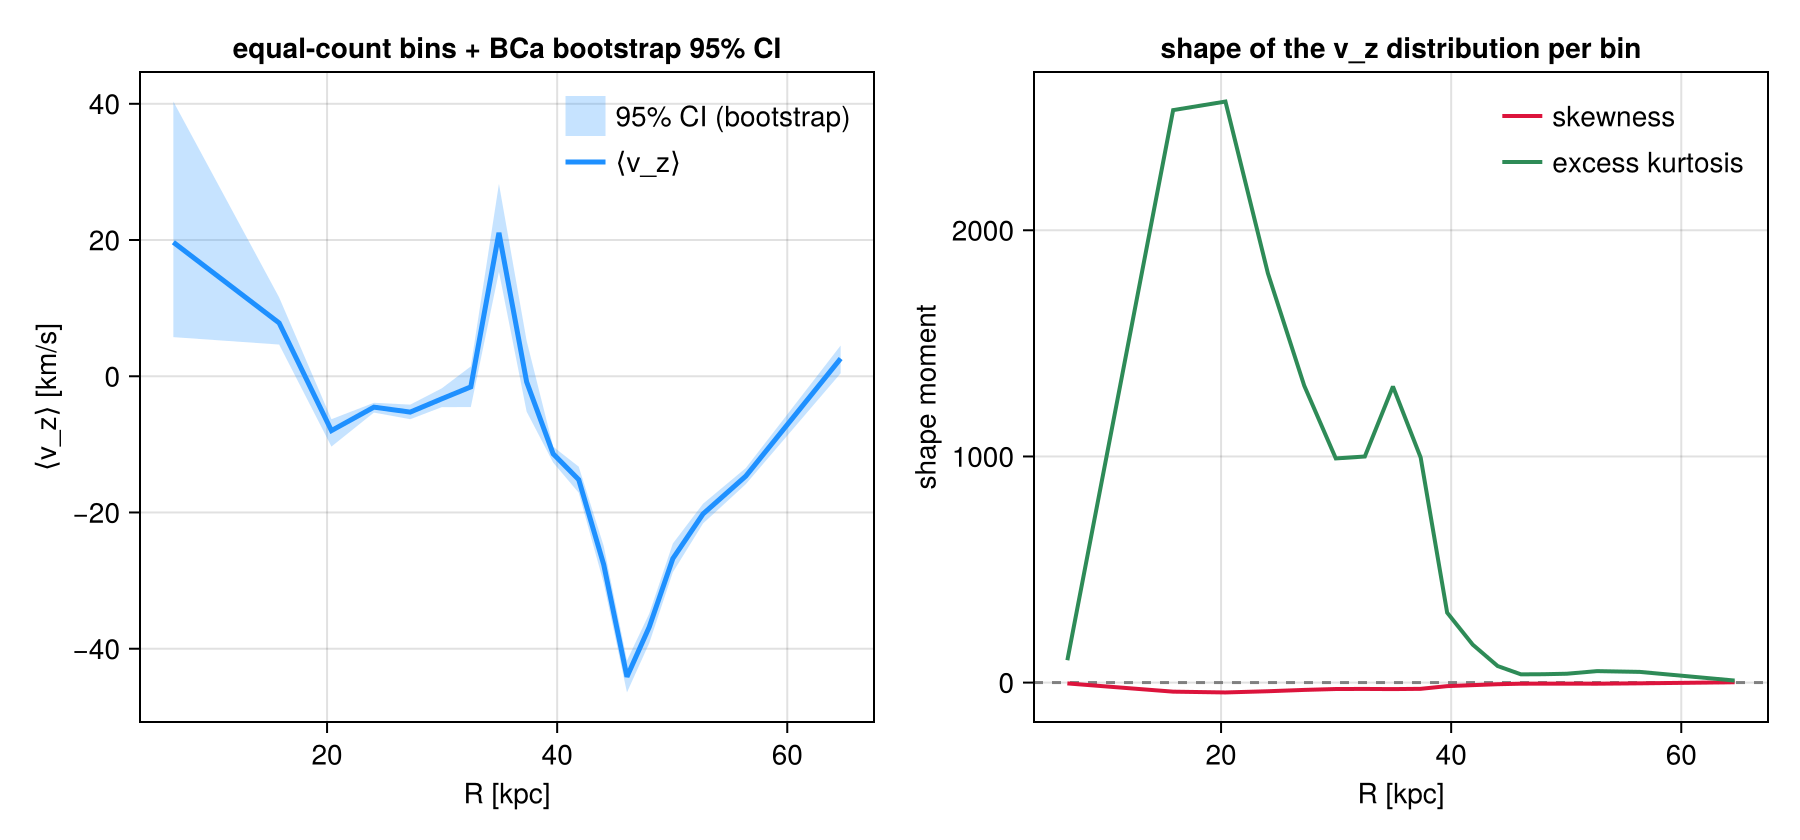

In [15]:
pe = profile(gas, :r_cylinder, :vz; weight=:mass, unit=:km_s, scale=:equal, nbins=18,
             center=ctr, range_unit=:kpc, xunit=:kpc, bootstrap=800, ci=:bca, confidence_level=0.95)
println("equal-count points/bin (min..max): ", extrema(pe.count), "  → nearly equal")
ok = pe.count .> 5
x = pe.x[ok]; mu = pe.mean[ok]; lo = pe.mean_ci[ok,1]; hi = pe.mean_ci[ok,2]
sk = pe.skewness[ok]; ku = pe.kurtosis[ok]
fig = Figure(size=(900,420))
ax1 = Axis(fig[1,1], xlabel="R [kpc]", ylabel="⟨v_z⟩ [km/s]", title="equal-count bins + BCa bootstrap 95% CI")
band!(ax1, x, lo, hi, color=(:dodgerblue,0.25), label="95% CI (bootstrap)")
lines!(ax1, x, mu, color=:dodgerblue, linewidth=2.5, label="⟨v_z⟩")
axislegend(ax1, position=:rt, framevisible=false)
ax2 = Axis(fig[1,2], xlabel="R [kpc]", ylabel="shape moment", title="shape of the v_z distribution per bin")
hlines!(ax2, [0.0], color=:gray, linestyle=:dash)
lines!(ax2, x, sk, color=:crimson, linewidth=2, label="skewness")
lines!(ax2, x, ku, color=:seagreen, linewidth=2, label="excess kurtosis")
axislegend(ax2, position=:rt, framevisible=false); fig

## More features (same API, no separate plot here)

These use exactly the same `profile`/`phase` calls shown above:

* **Many fields in one pass** — pass `yvar` as a vector to bin once and reduce several fields together
  (cheaper than one call per field); per-field stats live under `p.fields[:T]`, in `p.yvars` order:
  `profile(gas, :r_cylinder, [:T, :rho]; weight=:mass, nbins=40, center=ctr, range_unit=:kpc)`.
* **Velocity decomposition** — `getvar` splits each cell's velocity about `center` into
  `:vr_cylinder` (radial in/outflow, ±), `:vϕ_cylinder` (rotation), `:vz` (vertical), plus the
  spherical triplet `:vr_sphere`/`:vθ_sphere`/`:vϕ_sphere`. Profiling them gives ⟨v⟩(R) (`mean`,
  signed) and the **rest-frame dispersion** σ(R) (`std`, about the per-bin mean, so net rotation
  doesn't inflate it). [`velocitydispersion`](@ref) returns σ_R/σ_ϕ/σ_z and the total σ in one call.
  These are **3-D, per-annulus** dispersions about the bin mean (intra-bin shear retained); for a
  **local, per-pixel line-of-sight** dispersion use the projected `:σlos` map instead —
  `profile(projection(gas, :σlos, :km_s; direction=:edgeon, center=ctr, range_unit=:kpc), :σlos; xvar=:r, weight=:sd)`.
* **Select particles** — `getparticlemask(parts, :stars)` (or `:dm`/`:clouds`/… , a family `Int`, or
  `(family=…, tag=…)`) builds a boolean mask to pass as `mask=` to any profile call.
* **Profiles from a 2-D map** — `profile` also takes a `projection` result: bin map pixels by
  image-plane radius `:r` (a surface brightness Σ(R)), by `:x`/`:y`, or by another map; weight by
  `:none`/`:area` or a map key. Works for off-axis (e.g. edge-on) maps too — `:r` stays centred on
  the object. `profile(proj, :sd; xvar=:r, weight=:none, xunit=:kpc, nbins=30)`.
* **3-D profiles** — `profile3d(gas, :rho, :T, :z; weight=:mass, nbins=(80,80,24), …)` bins by three
  fields; marginalizing one axis reproduces `phase` exactly (a built-in consistency check).
* **Evolution across snapshots** — `profiletimeseries(loadfn, outputs, xvar, yvar; …)` stacks a
  profile over many outputs into an `(nbins × n_snapshots)` matrix on a fixed radius axis.

## Takeaway

| feature | call |
|---|---|
| bin a quantity; log/custom `edges` | `profile(obj, x)` |
| per-bin mean/std/sem/quantiles/min/max/custom | `profile(obj, x, y; statistic=…)` |
| density / enclosed mass / fraction / pdf | `geometry`, `cumulative`, `normalize` |
| many fields in one pass | `profile(obj, x, [y1,y2])` → `.fields` |
| mass/volume/none/field weighting; components | `weight=…`, shared `edges` |
| rotation curve — gas (maskable) / stars / DM | `rotationcurve(obj; mask=…)` |
| velocity decomposition ⟨v_ϕ⟩/⟨v_r⟩ + σ_r/σ_ϕ/σ_z | `profile(obj, r, :vϕ_cylinder/:vr_cylinder/:vz)` |
| select particles by type/family/tag | `getparticlemask` |
| profile from a 2-D map (Σ(R), map-weighted) | `profile(m::DataMapsType, …)` |
| 2-D phase; colour by mean/std/…; PDF | `phase(obj, x, y[, c]; cstat, normalize)` |
| 3-D histogram; marginal == phase | `profile3d` |
| radius-vs-time evolution | `profiletimeseries` |
| distribution shape; equal-count bins; bootstrap CIs | `skewness`/`kurtosis`, `scale=:equal`, `bootstrap=N` |

Profiles & phase work on **gas, gravity, particles and projected maps** (`source=:data`
or `:map`). Everything here is regression-tested in the Mera test suite. For *line-of-sight*
distributions (per-pixel spectra, velocity cubes) see the [Off-axis Projection](06_offaxis_Projection.md) guide.